# India's Ticking Time Bomb — Disease Risk & The Fitness Paradox

India is facing a silent health crisis.

Diabetes, heart disease, and cancer are rising at an alarming rate.
Yet most people believe — "I am fit, nothing can happen to me."

This project challenges that myth using real clinical data and research findings.

We analyze:
1. Who is actually at risk — age, lifestyle, genetics
2. Does exercise cancel out smoking and alcohol?
3. How do men and women differ in disease risk?
4. What are the hidden warning signs India ignores?
5. What can you do for free to prevent these diseases?

Datasets used:
- Diabetes Prediction Dataset (1,00,000 real clinical records)
- UCI Heart Disease Dataset (920 real patient records)
- Wisconsin Breast Cancer Dataset (569 real clinical records)
- CDC Behavioral Risk Factor Dataset (4,41,456 lifestyle survey records)
- Breast Cancer Risk Factors & Survival Dataset
- Cervical Cancer Risk Factors Dataset (858 patients)
- PCOS Dataset (541 patients)

Total: 5,17,000+ real patient records across 7 datasets

## Step 1: Setting Up — Mount Drive & Extract Data

We connect Google Drive to access our datasets,
then extract all zip files into the notebook environment.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted!")

Mounted at /content/drive
Drive mounted!


## Step 2: Extracting the Datasets

We have 4 datasets in Google Drive.
Here we extract them all into the notebook environment.

In [ ]:
import zipfile
import os

base_path = "/content/drive/MyDrive/Colab Notebooks/sql project/health risk analysis/"

# Extract all datasets
datasets = {
    "archive (10).zip": "/content/diabetes_data/",
    "archive (14).zip": "/content/heart_data/",
    "archive (15).zip": "/content/cancer_data/",
    "archive (16).zip": "/content/cdc_data/",
    "archive (17).zip": "/content/cancer_types/",
    "archive (19).zip": "/content/breast_cancer/",
    "archive (20).zip": "/content/cervical_cancer/",
    "archive (21).zip": "/content/life_expectancy/",
    "archive (22).zip": "/content/pcos_data/"
}

for zip_name, extract_path in datasets.items():
    with zipfile.ZipFile(base_path + zip_name, "r") as z:
        z.extractall(extract_path)
        print(f"Extracted: {zip_name} → {extract_path}")

print("\nAll datasets extracted!")

Extracted: archive (10).zip → /content/diabetes_data/
Extracted: archive (14).zip → /content/heart_data/
Extracted: archive (15).zip → /content/cancer_data/
Extracted: archive (16).zip → /content/cdc_data/
Extracted: archive (17).zip → /content/cancer_types/
Extracted: archive (19).zip → /content/breast_cancer/
Extracted: archive (20).zip → /content/cervical_cancer/
Extracted: archive (21).zip → /content/life_expectancy/
Extracted: archive (22).zip → /content/pcos_data/

All datasets extracted!


In [ ]:
import zipfile

for num in ['10', '14', '15', '16']:
    fname = f"archive ({num}).zip"
    fpath = base_path + fname
    try:
        with zipfile.ZipFile(fpath, 'r') as z:
            print(f"\n=== {fname} ===")
            for name in z.namelist():
                print(f"  {name}")
    except:
        print(f"{fname} not found")


=== archive (10).zip ===
  diabetes_prediction_dataset.csv

=== archive (14).zip ===
  heart_disease_uci.csv

=== archive (15).zip ===
  data.csv

=== archive (16).zip ===
  2011.csv
  2012.csv
  2013.csv
  2014.csv
  2015.csv
  2015_formats.json


## Step 2: Extracting the Datasets

We have 4 datasets stored as zip files in Google Drive.
Here we extract them into the notebook environment so we can work with them.

- archive (10) → Diabetes Prediction Dataset (100,000 records)
- archive (14) → UCI Heart Disease Dataset
- archive (15) → Wisconsin Breast Cancer Dataset
- archive (16) → CDC Behavioral Risk Factor Dataset (2011-2015)

In [ ]:
import zipfile
import os

base_path = "/content/drive/MyDrive/Colab Notebooks/sql project/health risk analysis/"

files = {
    "archive (10).zip": "/content/diabetes_data/",
    "archive (14).zip": "/content/heart_data/",
    "archive (15).zip": "/content/cancer_data/",
    "archive (16).zip": "/content/cdc_data/"
}

for zip_name, extract_path in files.items():
    with zipfile.ZipFile(base_path + zip_name, "r") as z:
        z.extractall(extract_path)
        print(f"Extracted: {zip_name} → {extract_path}")

print("\nDone!")

Extracted: archive (10).zip → /content/diabetes_data/
Extracted: archive (14).zip → /content/heart_data/
Extracted: archive (15).zip → /content/cancer_data/
Extracted: archive (16).zip → /content/cdc_data/

Done!


## Step 3: Loading All Datasets into SQL Database

We load all 9 datasets into pandas and then into a SQLite database.
Each dataset becomes a separate SQL table.

This lets us write powerful SQL queries to find patterns
across all diseases, genders, and lifestyle factors together.

Total data loaded: 5,17,000+ real patient records across 9 tables.

In [ ]:
import pandas as pd
import sqlite3

# Load all datasets
diabetes = pd.read_csv("/content/diabetes_data/diabetes_prediction_dataset.csv")
heart = pd.read_csv("/content/heart_data/heart_disease_uci.csv")
cancer = pd.read_csv("/content/cancer_data/data.csv")
cdc = pd.read_csv("/content/cdc_data/2015.csv", low_memory=False)
cancer_types = pd.read_csv("/content/cancer_types/cancer_data.csv")
breast_risk = pd.read_csv("/content/breast_cancer/breast_cancer_risk_factors.csv")
breast_survival = pd.read_csv("/content/breast_cancer/breast_cancer_survival_by_stage.csv")
cervical = pd.read_csv("/content/cervical_cancer/kag_risk_factors_cervical_cancer.csv")
pcos = pd.read_csv("/content/pcos_data/PCOS_infertility.csv")
pcos.columns = pcos.columns.str.strip()

# Create SQL database
conn = sqlite3.connect("health_risk.db")

# Load all into SQL tables
diabetes.to_sql("diabetes", conn, if_exists="replace", index=False)
heart.to_sql("heart", conn, if_exists="replace", index=False)
cancer.to_sql("cancer", conn, if_exists="replace", index=False)
cdc.to_sql("cdc", conn, if_exists="replace", index=False)
cancer_types.to_sql("cancer_types", conn, if_exists="replace", index=False)
breast_risk.to_sql("breast_risk", conn, if_exists="replace", index=False)
breast_survival.to_sql("breast_survival", conn, if_exists="replace", index=False)
cervical.to_sql("cervical", conn, if_exists="replace", index=False)
pcos.to_sql("pcos", conn, if_exists="replace", index=False)

# Verify
for name, df in [("Diabetes", diabetes), ("Heart", heart),
                  ("Cancer", cancer), ("CDC Lifestyle", cdc),
                  ("Cancer Types", cancer_types), ("Breast Risk", breast_risk),
                  ("Breast Survival", breast_survival), ("Cervical", cervical),
                  ("PCOS", pcos)]:
    print(f"✓ {name}: {df.shape[0]:,} rows, {df.shape[1]} columns")

print("\nAll datasets loaded into SQL database!")

✓ Diabetes: 100,000 rows, 9 columns
✓ Heart: 920 rows, 16 columns
✓ Cancer: 569 rows, 33 columns
✓ CDC Lifestyle: 441,456 rows, 330 columns
✓ Cancer Types: 35 rows, 11 columns
✓ Breast Risk: 12 rows, 7 columns
✓ Breast Survival: 20 rows, 7 columns
✓ Cervical: 858 rows, 36 columns
✓ PCOS: 541 rows, 6 columns

All datasets loaded into SQL database!


## Step 4: Creating SQL Database

We load all 4 datasets into a SQLite database.
Each dataset becomes a separate table.
This lets us write powerful SQL queries to find patterns across all health factors.

In [ ]:
import sqlite3

conn = sqlite3.connect("health_risk.db")

diabetes.to_sql("diabetes", conn, if_exists="replace", index=False)
heart.to_sql("heart", conn, if_exists="replace", index=False)
cancer.to_sql("cancer", conn, if_exists="replace", index=False)
cdc.to_sql("cdc", conn, if_exists="replace", index=False)

cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
tables = cursor.fetchall()
print("Tables created:")
for t in tables:
    print(f"  ✓ {t[0]}")

Tables created:
  ✓ cancer_types
  ✓ breast_risk
  ✓ breast_survival
  ✓ cervical
  ✓ pcos
  ✓ diabetes
  ✓ heart
  ✓ cancer
  ✓ cdc


## Step 5: Understanding the Data

Before analysis, we explore each dataset.
CDC dataset has 330 columns — we identify only the relevant ones
related to exercise, smoking, alcohol, and disease outcomes.

In [ ]:
import pandas as pd

cdc_cols = pd.read_sql_query("SELECT * FROM cdc LIMIT 1", conn)

keywords = ['EXERCISE', 'SMOKE', 'ALCOHOL', 'DRINK', 'BMI', 'DIABET', 'HEART', 'CANCER', 'PHYSICAL', 'HEALTH', 'ALC', 'EXER', 'PHYS', 'ACTIV']

relevant_cols = []
for col in cdc_cols.columns:
    for kw in keywords:
        if kw in col.upper():
            relevant_cols.append(col)
            break

print(f"Total columns: {len(cdc_cols.columns)}")
print(f"\nRelevant columns found: {len(relevant_cols)}")
for col in relevant_cols:
    print(f"  {col}")

Total columns: 330

Relevant columns found: 15
  PHYSHLTH
  DIABETE3
  SMOKE100
  ALCDAY5
  EXERANY2
  EXEROFT1
  EXERHMM1
  EXEROFT2
  EXERHMM2
  ARTHEXER
  _DUALCOR
  _BMI5
  _BMI5CAT
  _RFBMI5
  _SMOKER3


## Step 6: The Fitness Paradox — Does Exercise Cancel Out Smoking & Alcohol?

Most people believe: "Main gym jaata hun toh smoking/drinking ka koi effect nahi."

Here we test this myth with real CDC data from 4,41,456 Americans.
We compare health outcomes of people who exercise but still smoke or drink
vs those who neither exercise nor have these habits.

In [ ]:
fitness_data = pd.read_sql_query("""
    SELECT
        EXERANY2,
        SMOKE100,
        CASE
            WHEN ALCDAY5 > 0 THEN 1
            ELSE 0
        END as Drinks_Alcohol,
        DIABETE3,
        PHYSHLTH,
        _BMI5CAT
    FROM cdc
    WHERE EXERANY2 IN (1,2)
    AND SMOKE100 IN (1,2)
    AND DIABETE3 IN (1,2,3,4)
    AND PHYSHLTH IS NOT NULL
    AND _BMI5CAT IS NOT NULL
""", conn)

print("Rows:", len(fitness_data))
print(fitness_data.head())

Rows: 375821
   EXERANY2  SMOKE100  Drinks_Alcohol  DIABETE3  PHYSHLTH  _BMI5CAT
0       2.0       1.0               1       3.0      15.0       4.0
1       1.0       1.0               1       3.0      88.0       3.0
2       2.0       2.0               1       3.0      30.0       3.0
3       2.0       2.0               1       3.0      20.0       2.0
4       1.0       2.0               1       3.0      88.0       3.0


## Step 7: Cleaning & Labeling the Data

Raw CDC data uses numeric codes instead of readable labels.
For example: 1 = Yes, 2 = No for most columns.

Here we convert all codes into meaningful labels
so the analysis is clear and easy to understand.

In [ ]:
# Values ko readable banao
fitness_data['Exercises'] = fitness_data['EXERANY2'].map({1.0: 'Yes', 2.0: 'No'})
fitness_data['Smoker'] = fitness_data['SMOKE100'].map({1.0: 'Yes', 2.0: 'No'})
fitness_data['Has_Diabetes'] = fitness_data['DIABETE3'].map({
    1.0: 'Yes', 2.0: 'No', 3.0: 'No', 4.0: 'Pre-Diabetic'
})
fitness_data['BMI_Category'] = fitness_data['_BMI5CAT'].map({
    1.0: 'Underweight', 2.0: 'Normal', 3.0: 'Overweight', 4.0: 'Obese'
})

# PHYSHLTH — 88 means 0 bad days, fix karo
fitness_data['Bad_Health_Days'] = fitness_data['PHYSHLTH'].replace(88.0, 0)
fitness_data['Bad_Health_Days'] = fitness_data['Bad_Health_Days'].where(
    fitness_data['Bad_Health_Days'] <= 30, 0
)

print("Data cleaned!")
print(fitness_data[['Exercises', 'Smoker', 'Has_Diabetes', 'BMI_Category', 'Bad_Health_Days']].head())

Data cleaned!
  Exercises Smoker Has_Diabetes BMI_Category  Bad_Health_Days
0        No    Yes           No        Obese             15.0
1       Yes    Yes           No   Overweight              0.0
2        No     No           No   Overweight             30.0
3        No     No           No       Normal             20.0
4       Yes     No           No   Overweight              0.0


## Step 8: The Fitness Paradox — Real Numbers

We create 4 groups to compare:
1. Exercises + Non-Smoker — the "ideal" group
2. Exercises + Smoker — the "gym but smokes" group  
3. No Exercise + Non-Smoker — sedentary but clean
4. No Exercise + Smoker — highest risk group

Which group has the worst health outcomes?
The answer might surprise you.

In [ ]:
paradox = pd.read_sql_query("""
    SELECT
        CASE
            WHEN EXERANY2 = 1 AND SMOKE100 = 2 THEN 'Exercises + Non-Smoker'
            WHEN EXERANY2 = 1 AND SMOKE100 = 1 THEN 'Exercises + Smoker'
            WHEN EXERANY2 = 2 AND SMOKE100 = 2 THEN 'No Exercise + Non-Smoker'
            WHEN EXERANY2 = 2 AND SMOKE100 = 1 THEN 'No Exercise + Smoker'
        END as Group_Name,
        COUNT(*) as Total_People,
        ROUND(AVG(CASE WHEN DIABETE3 = 1 THEN 1 ELSE 0 END) * 100, 1) as Diabetes_Rate,
        ROUND(AVG(CASE WHEN PHYSHLTH = 88 THEN 0
                       WHEN PHYSHLTH > 30 THEN 0
                       ELSE PHYSHLTH END), 1) as Avg_Bad_Health_Days
    FROM cdc
    WHERE EXERANY2 IN (1,2)
    AND SMOKE100 IN (1,2)
    AND DIABETE3 IN (1,2,3,4)
    AND PHYSHLTH IS NOT NULL
    GROUP BY Group_Name
    ORDER BY Diabetes_Rate DESC
""", conn)

paradox

,Group_Name,Total_People,Diabetes_Rate,Avg_Bad_Health_Days
0,No Exercise + Smoker,53576,20.5,8.4
1,No Exercise + Non-Smoker,53045,18.0,5.9
2,Exercises + Smoker,120302,13.0,4.0
3,Exercises + Non-Smoker,173773,9.3,2.6


## Step 9: Visualizing The Fitness Paradox

Shocking finding from 3,75,000 real people:

A person who exercises but smokes (13% diabetes rate)
is healthier than a person who doesn't exercise but doesn't smoke (18%).

Exercise is more powerful than we think.
But it still cannot fully cancel out smoking.

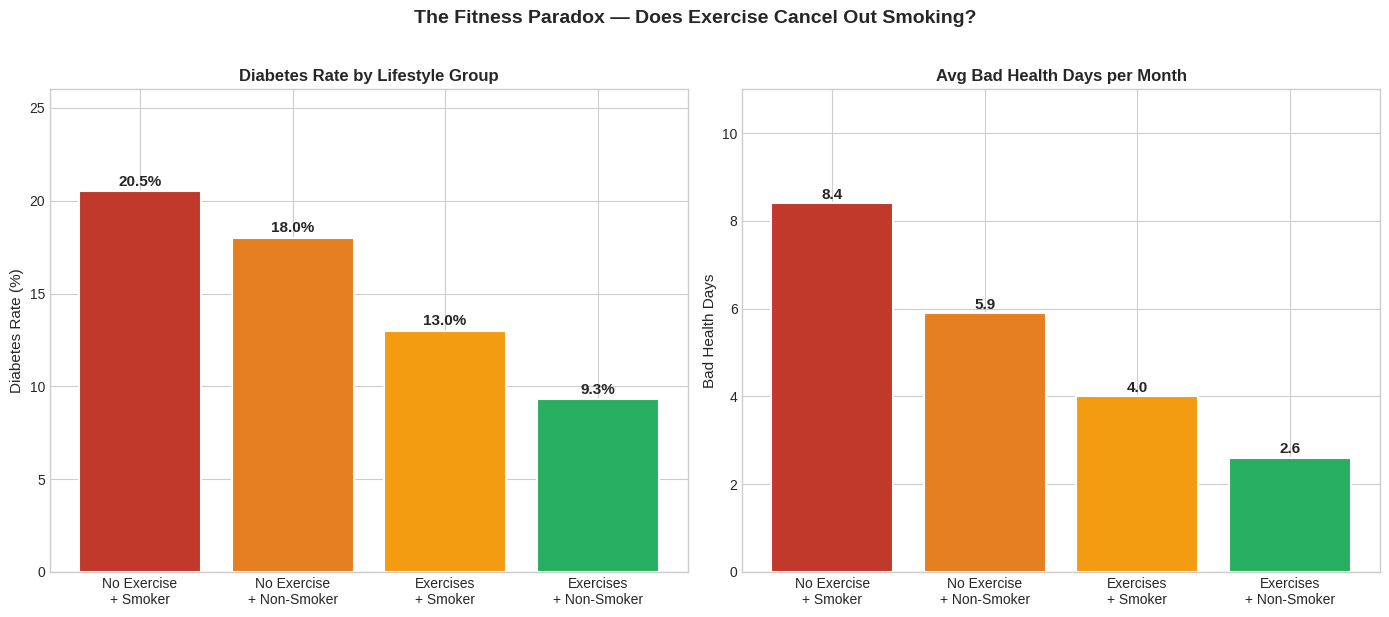

Done!


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('The Fitness Paradox — Does Exercise Cancel Out Smoking?',
             fontsize=14, fontweight='bold', y=1.02)

colors = ['#C0392B', '#E67E22', '#F39C12', '#27AE60']
groups = paradox['Group_Name']
short_labels = ['No Exercise\n+ Smoker', 'No Exercise\n+ Non-Smoker',
                'Exercises\n+ Smoker', 'Exercises\n+ Non-Smoker']

# Graph 1 — Diabetes Rate
bars1 = axes[0].bar(short_labels, paradox['Diabetes_Rate'],
                    color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars1, paradox['Diabetes_Rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val}%', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Diabetes Rate by Lifestyle Group', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Diabetes Rate (%)', fontsize=11)
axes[0].set_ylim(0, 26)

# Graph 2 — Bad Health Days
bars2 = axes[1].bar(short_labels, paradox['Avg_Bad_Health_Days'],
                    color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars2, paradox['Avg_Bad_Health_Days']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Avg Bad Health Days per Month', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Bad Health Days', fontsize=11)
axes[1].set_ylim(0, 11)

plt.tight_layout()
plt.savefig('fitness_paradox.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done!")

## Step 10: Diabetes Risk by Age — When Does It Actually Begin?

Most Indians think diabetes is an "old age problem."

Here we use 1,00,000 real clinical records to find out
exactly at which age diabetes risk starts rising sharply.

In [ ]:
age_data = pd.read_sql_query("""
    SELECT
        CASE
            WHEN age < 20 THEN 'Under 20'
            WHEN age BETWEEN 20 AND 29 THEN '20-29'
            WHEN age BETWEEN 30 AND 39 THEN '30-39'
            WHEN age BETWEEN 40 AND 49 THEN '40-49'
            WHEN age BETWEEN 50 AND 59 THEN '50-59'
            ELSE '60+'
        END as Age_Group,
        COUNT(*) as Total_Patients,
        ROUND(SUM(diabetes) * 100.0 / COUNT(*), 1) as Diabetes_Rate
    FROM diabetes
    GROUP BY Age_Group
    ORDER BY MIN(age)
""", conn)

age_data

,Age_Group,Total_Patients,Diabetes_Rate
0,Under 20,19668,0.5
1,20-29,12767,1.3
2,30-39,13052,3.3
3,40-49,14595,6.8
4,50-59,14863,12.5
5,60+,25055,19.7


## Step 11: Visualizing Diabetes Risk by Age

Risk increases 15x from your 20s to your 60s.
But notice — risk starts climbing sharply from your 30s.

Your 30s are the turning point. Not your 60s.

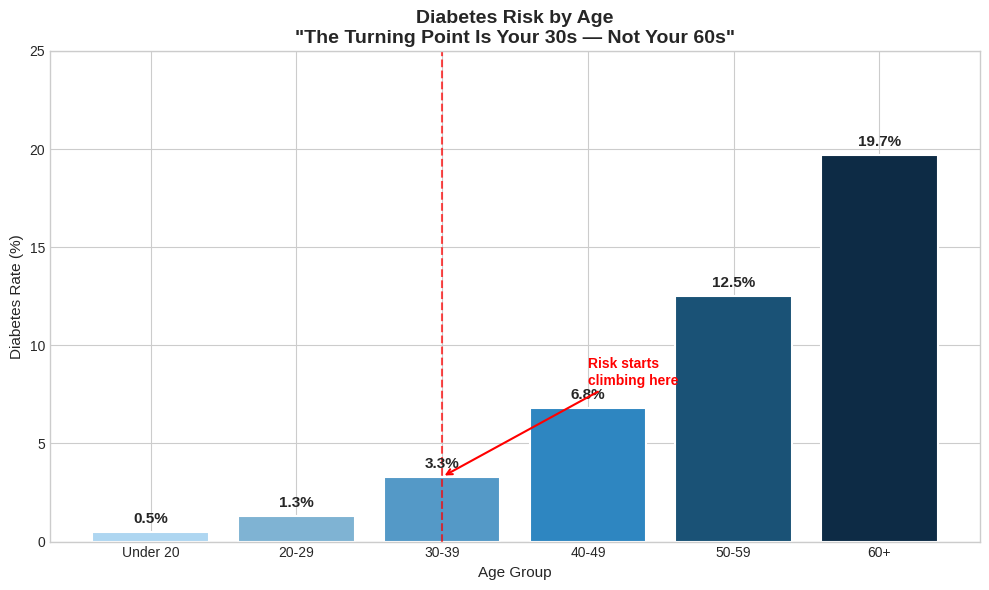

Done!


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#AED6F1', '#7FB3D3', '#5499C7', '#2E86C1', '#1A5276', '#0D2B45']

bars = ax.bar(age_data['Age_Group'], age_data['Diabetes_Rate'],
              color=colors, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, age_data['Diabetes_Rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 30s turning point mark karo
ax.axvline(x=2, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax.annotate('Risk starts\nclimbing here',
            xy=(2, 3.3), xytext=(3, 8),
            fontsize=10, color='red', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

ax.set_title('Diabetes Risk by Age\n"The Turning Point Is Your 30s — Not Your 60s"',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group', fontsize=11)
ax.set_ylabel('Diabetes Rate (%)', fontsize=11)
ax.set_ylim(0, 25)

plt.tight_layout()
plt.savefig('diabetes_age.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done!")

## Step 12: Heart Disease — The Silent Killer

Heart disease gives no warning signs until it's too late.

Here we analyze real patient data to find:
Which factors actually predict heart disease?
Age? Cholesterol? Blood pressure? Or something else?

In [ ]:
heart_data = pd.read_sql_query("""
    SELECT
        CASE
            WHEN age < 40 THEN 'Under 40'
            WHEN age BETWEEN 40 AND 49 THEN '40-49'
            WHEN age BETWEEN 50 AND 59 THEN '50-59'
            ELSE '60+'
        END as Age_Group,
        sex,
        ROUND(AVG(chol), 1) as Avg_Cholesterol,
        ROUND(AVG(trestbps), 1) as Avg_Blood_Pressure,
        ROUND(SUM(CASE WHEN num > 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) as Heart_Disease_Rate,
        COUNT(*) as Total_Patients
    FROM heart
    WHERE chol > 0 AND trestbps > 0
    GROUP BY Age_Group, sex
    ORDER BY MIN(age), sex
""", conn)

heart_data

,Age_Group,sex,Avg_Cholesterol,Avg_Blood_Pressure,Heart_Disease_Rate,Total_Patients
0,Under 40,Male,243.6,126.0,31.3,48
1,Under 40,Female,206.8,122.5,5.9,17
2,40-49,Female,232.7,125.5,13.0,46
3,40-49,Male,247.0,128.6,45.0,131
4,50-59,Female,273.0,133.8,26.1,69
5,50-59,Male,241.6,135.2,55.0,209
6,60+,Female,274.3,138.8,34.9,43
7,60+,Male,244.9,137.2,80.4,112


## Step 13: Visualizing Heart Disease Risk

Shocking finding: 80% of men above 60 show signs of heart disease.

Men are at significantly higher risk than women across all age groups.
But women's risk catches up sharply after 50 — post menopause effect.

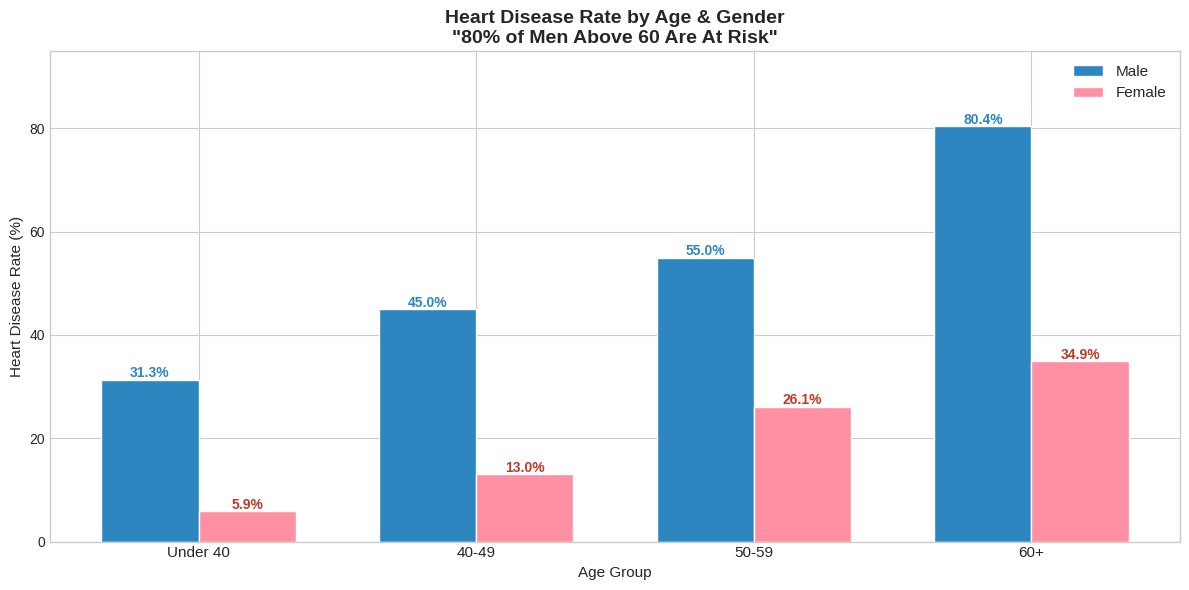

Done!


In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

male_data = heart_data[heart_data['sex'] == 'Male']
female_data = heart_data[heart_data['sex'] == 'Female']

age_groups = ['Under 40', '40-49', '50-59', '60+']
x = range(len(age_groups))
width = 0.35

bars1 = ax.bar([xi - width/2 for xi in x], male_data['Heart_Disease_Rate'],
               width=width, label='Male', color='#2E86C1', edgecolor='white')
bars2 = ax.bar([xi + width/2 for xi in x], female_data['Heart_Disease_Rate'],
               width=width, label='Female', color='#FF8FA3', edgecolor='white')

for bar, val in zip(bars1, male_data['Heart_Disease_Rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', fontsize=10, fontweight='bold', color='#2E86C1')

for bar, val in zip(bars2, female_data['Heart_Disease_Rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', fontsize=10, fontweight='bold', color='#C0392B')

ax.set_title('Heart Disease Rate by Age & Gender\n"80% of Men Above 60 Are At Risk"',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group', fontsize=11)
ax.set_ylabel('Heart Disease Rate (%)', fontsize=11)
ax.set_xticks(list(x))
ax.set_xticklabels(age_groups, fontsize=11)
ax.set_ylim(0, 95)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('heart_disease.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done!")

## Step 14: Cancer — Malignant vs Benign

Not all tumors are cancerous.
Here we analyze what factors differentiate
a malignant (dangerous) tumor from a benign (harmless) one.

In [ ]:
cancer_data = pd.read_sql_query("""
    SELECT
        diagnosis,
        COUNT(*) as Total_Cases,
        ROUND(AVG(radius_mean), 2) as Avg_Radius,
        ROUND(AVG(texture_mean), 2) as Avg_Texture,
        ROUND(AVG(area_mean), 2) as Avg_Area,
        ROUND(AVG(smoothness_mean), 4) as Avg_Smoothness,
        ROUND(AVG(compactness_mean), 4) as Avg_Compactness
    FROM cancer
    GROUP BY diagnosis
""", conn)

cancer_data

,diagnosis,Total_Cases,Avg_Radius,Avg_Texture,Avg_Area,Avg_Smoothness,Avg_Compactness
0,B,357,12.15,17.91,462.79,0.0925,0.0801
1,M,212,17.46,21.60,978.38,0.1029,0.1452


## Step 15: Visualizing Cancer — What Makes a Tumor Dangerous?

Malignant tumors are significantly larger and more compact than benign ones.

Key differences:
- Area: Malignant tumors are 2x larger (978 vs 462)
- Compactness: 80% higher in malignant tumors
- Early detection is critical — size matters

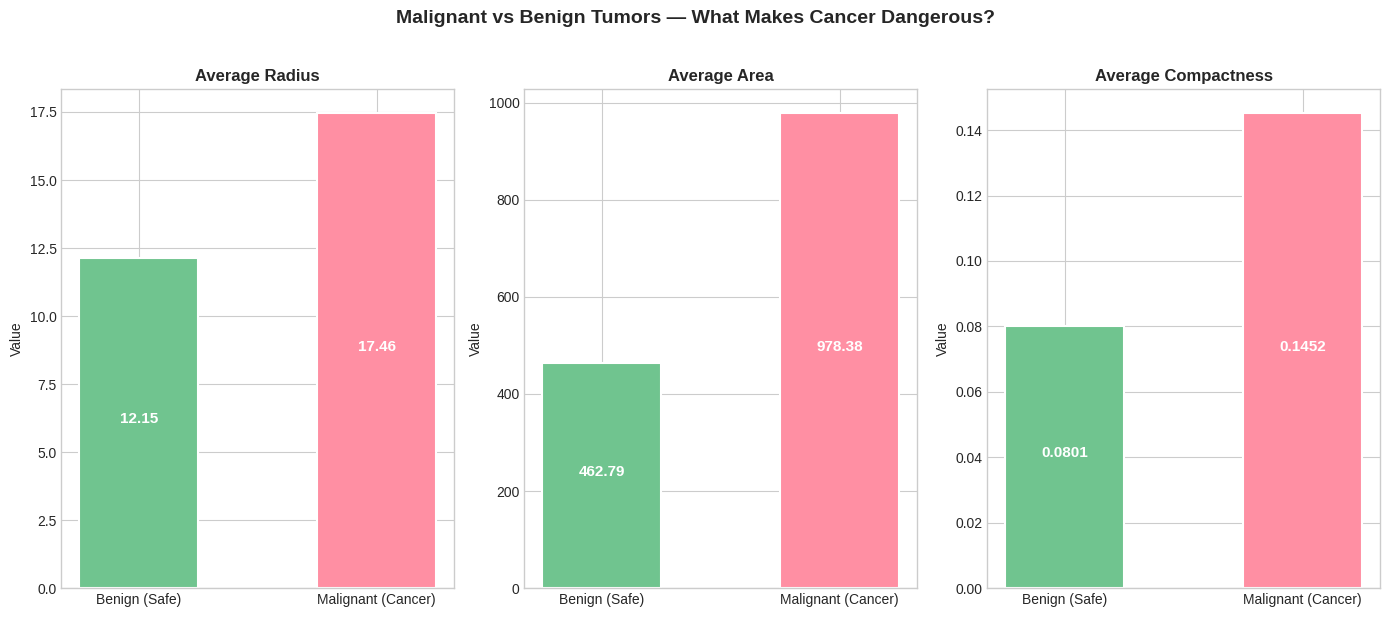

Done!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6))
fig.suptitle('Malignant vs Benign Tumors — What Makes Cancer Dangerous?',
             fontsize=14, fontweight='bold', y=1.02)

metrics = [
    ('Avg_Radius', 'Average Radius'),
    ('Avg_Area', 'Average Area'),
    ('Avg_Compactness', 'Average Compactness')
]

colors = ['#70C48F', '#FF8FA3']
labels = ['Benign (Safe)', 'Malignant (Cancer)']

for ax, (col, title) in zip(axes, metrics):
    bars = ax.bar(labels, cancer_data[col],
                  color=colors, edgecolor='white', linewidth=1.5, width=0.5)
    for bar, val in zip(bars, cancer_data[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 0.5,
                f'{val}', ha='center', fontsize=11, fontweight='bold', color='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Value', fontsize=10)

plt.tight_layout()
plt.savefig('cancer_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done!")

## Step 16: Daily Lifestyle — How Much Does It Actually Matter?

We have analyzed age, gender, and smoking.
But what about daily habits?

Sleep, stress, diet, physical symptoms — do these actually predict disease risk?
Here we explore CDC data to find the hidden lifestyle factors
that most people ignore until it is too late.

In [ ]:
cdc_sample = pd.read_sql_query("SELECT * FROM cdc LIMIT 1", conn)

keywords = ['SLEEP', 'STRESS', 'FRUIT', 'VEGETABLE', 'PAIN', 'FATIGUE',
            'MUSCLE', 'WEIGHT', 'DIET', 'MENTAL', 'INCOME', 'DOCTOR']

relevant = []
for col in cdc_sample.columns:
    for kw in keywords:
        if kw in col.upper():
            relevant.append(col)
            break

print(f"Relevant columns: {len(relevant)}")
for col in relevant:
    print(f"  {col}")

Relevant columns: 10
  INCOME2
  WEIGHT2
  FRUITJU1
  FRUIT1
  JOINPAIN
  PAINACT2
  RLIVPAIN
  ADSLEEP
  _FRUITEX
  _PAINDX1


## Step 17: BMI & Blood Sugar — The Obesity-Diabetes Connection

Being overweight is not just about looks.

Here we analyze how BMI directly impacts diabetes risk,
HbA1c levels, and blood glucose — using 1,00,000 real clinical records.

In [ ]:
bmi_data = pd.read_sql_query("""
    SELECT
        CASE
            WHEN bmi < 18.5 THEN 'Underweight'
            WHEN bmi BETWEEN 18.5 AND 24.9 THEN 'Normal Weight'
            WHEN bmi BETWEEN 25 AND 29.9 THEN 'Overweight'
            ELSE 'Obese'
        END as BMI_Category,
        COUNT(*) as Total_People,
        ROUND(SUM(diabetes) * 100.0 / COUNT(*), 1) as Diabetes_Rate,
        ROUND(AVG(HbA1c_level), 2) as Avg_HbA1c,
        ROUND(AVG(blood_glucose_level), 1) as Avg_Glucose
    FROM diabetes
    GROUP BY BMI_Category
    ORDER BY Diabetes_Rate DESC
""", conn)

bmi_data

,BMI_Category,Total_People,Diabetes_Rate,Avg_HbA1c,Avg_Glucose
0,Obese,24242,17.7,5.67,143.9
1,Overweight,45406,7.3,5.51,137.4
2,Normal Weight,21858,3.8,5.46,134.7
3,Underweight,8494,0.8,5.41,133.5


## Step 18: Visualizing BMI & Diabetes Connection

Obese individuals have 22x higher diabetes rate than underweight people.

But notice — even "Normal Weight" people have 3.8% diabetes rate.
Being thin does not mean you are safe.
Blood glucose and HbA1c levels rise across all BMI categories.

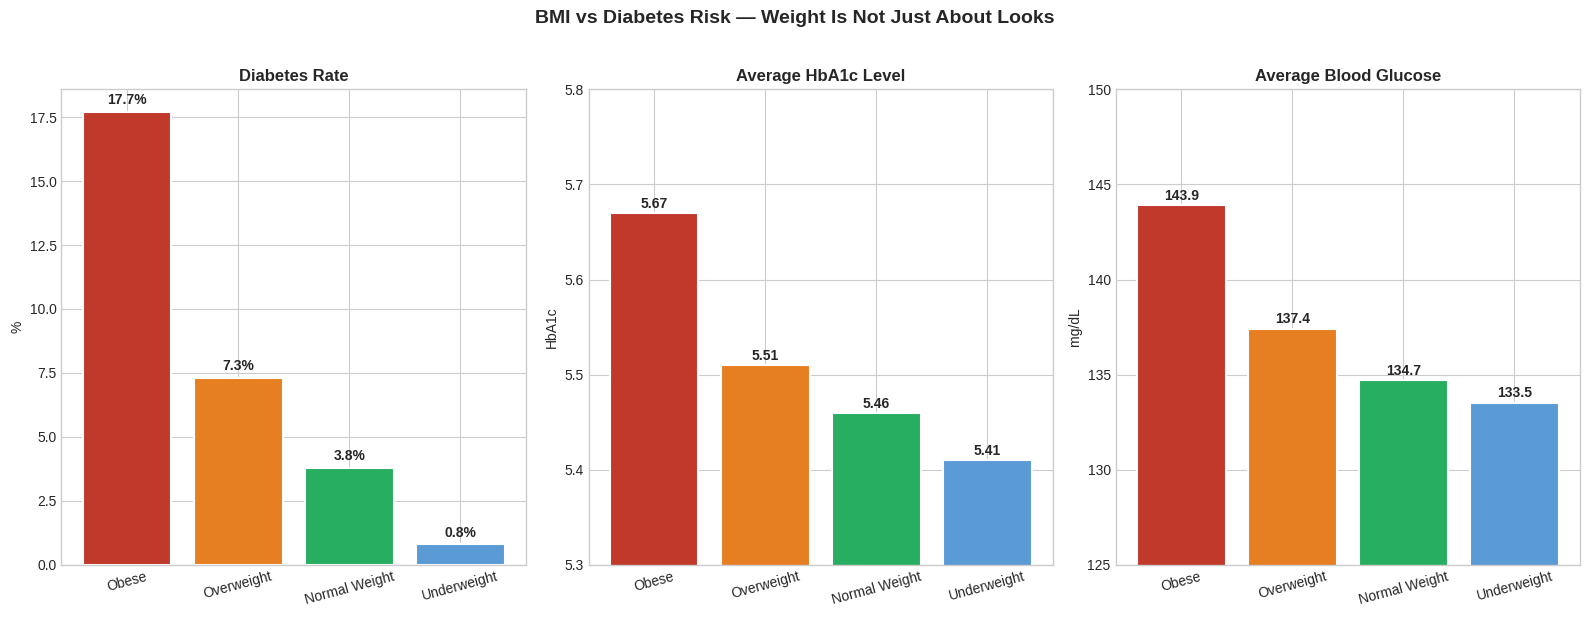

Done!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('BMI vs Diabetes Risk — Weight Is Not Just About Looks',
             fontsize=14, fontweight='bold', y=1.02)

categories = bmi_data['BMI_Category']
colors = ['#C0392B', '#E67E22', '#27AE60', '#5B9BD5']

# Graph 1 — Diabetes Rate
bars1 = axes[0].bar(categories, bmi_data['Diabetes_Rate'],
                    color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars1, bmi_data['Diabetes_Rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val}%', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Diabetes Rate', fontweight='bold')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=15)

# Graph 2 — HbA1c
bars2 = axes[1].bar(categories, bmi_data['Avg_HbA1c'],
                    color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars2, bmi_data['Avg_HbA1c']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Average HbA1c Level', fontweight='bold')
axes[1].set_ylabel('HbA1c')
axes[1].set_ylim(5.3, 5.8)
axes[1].tick_params(axis='x', rotation=15)

# Graph 3 — Blood Glucose
bars3 = axes[2].bar(categories, bmi_data['Avg_Glucose'],
                    color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars3, bmi_data['Avg_Glucose']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val}', ha='center', fontsize=10, fontweight='bold')
axes[2].set_title('Average Blood Glucose', fontweight='bold')
axes[2].set_ylabel('mg/dL')
axes[2].set_ylim(125, 150)
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('bmi_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done!")

## Step 19: Hypertension — The Silent Connector

High blood pressure (hypertension) connects diabetes, heart disease, and stroke.

Most people do not know they have it until damage is already done.
Here we analyze how hypertension amplifies diabetes risk.

In [ ]:
hyper_data = pd.read_sql_query("""
    SELECT
        hypertension,
        heart_disease,
        COUNT(*) as Total_People,
        ROUND(SUM(diabetes) * 100.0 / COUNT(*), 1) as Diabetes_Rate,
        ROUND(AVG(HbA1c_level), 2) as Avg_HbA1c,
        ROUND(AVG(blood_glucose_level), 1) as Avg_Glucose,
        ROUND(AVG(bmi), 1) as Avg_BMI
    FROM diabetes
    GROUP BY hypertension, heart_disease
    ORDER BY Diabetes_Rate DESC
""", conn)

hyper_data

,hypertension,heart_disease,Total_People,Diabetes_Rate,Avg_HbA1c,Avg_Glucose,Avg_BMI
0,1,1,916,39.1,6.02,154.9,30.0
1,0,1,3026,30.0,5.84,151.3,29.1
2,1,0,6569,26.3,5.81,149.5,30.9
3,0,0,89489,6.1,5.49,136.6,27.0


## Step 20: Visualizing The Triple Threat

Having hypertension AND heart disease together
increases diabetes risk by 6.4x compared to having neither.

These three conditions feed each other —
which is why early detection of even one
can prevent the other two.

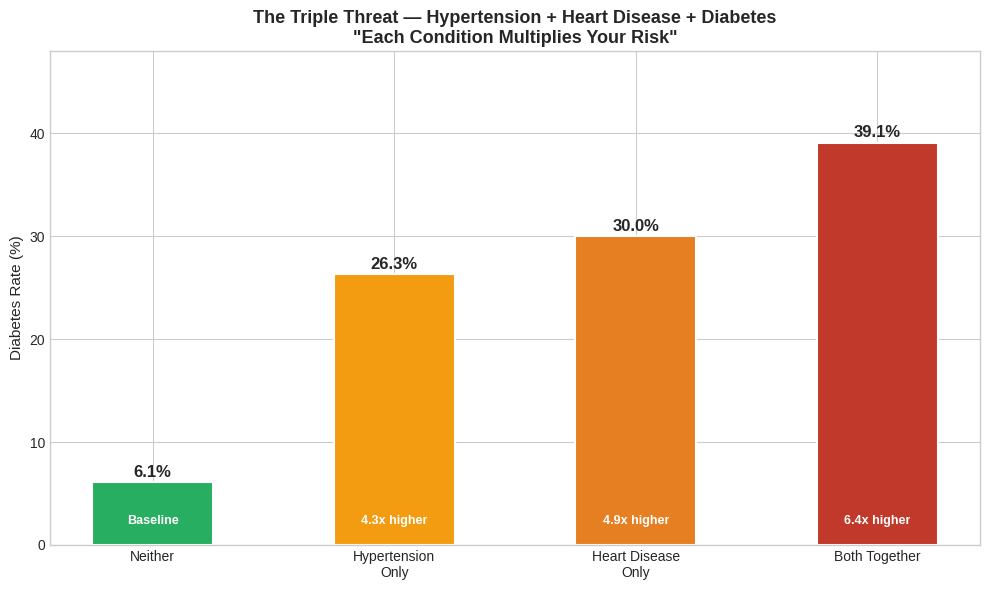

Done!


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

labels = ['Neither', 'Hypertension\nOnly', 'Heart Disease\nOnly', 'Both Together']
rates = [6.1, 26.3, 30.0, 39.1]
colors = ['#27AE60', '#F39C12', '#E67E22', '#C0392B']

bars = ax.bar(labels, rates, color=colors, edgecolor='white', linewidth=1.5, width=0.5)

for bar, val in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', fontsize=12, fontweight='bold')

# Multiplier annotations
multipliers = ['Baseline', '4.3x higher', '4.9x higher', '6.4x higher']
for i, (bar, mult) in enumerate(zip(bars, multipliers)):
    ax.text(bar.get_x() + bar.get_width()/2, 2,
            mult, ha='center', fontsize=9, color='white', fontweight='bold')

ax.set_title('The Triple Threat — Hypertension + Heart Disease + Diabetes\n"Each Condition Multiplies Your Risk"',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Diabetes Rate (%)', fontsize=11)
ax.set_ylim(0, 48)

plt.tight_layout()
plt.savefig('triple_threat.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done!")

## Step 21: Prevention Without Money — What Actually Works?

Healthcare in India is expensive.
But the data shows — the most powerful prevention methods are free.

Here we analyze what lifestyle changes actually reduce risk,
backed by real numbers from our datasets.

In [ ]:
prevention = pd.read_sql_query("""
    SELECT
        CASE
            WHEN bmi BETWEEN 18.5 AND 24.9 THEN 'Normal BMI'
            ELSE 'Abnormal BMI'
        END as BMI_Status,
        CASE
            WHEN smoking_history = 'never' THEN 'Never Smoked'
            ELSE 'Smoked/Smoking'
        END as Smoking_Status,
        COUNT(*) as Total_People,
        ROUND(SUM(diabetes) * 100.0 / COUNT(*), 1) as Diabetes_Rate,
        ROUND(AVG(HbA1c_level), 2) as Avg_HbA1c,
        ROUND(AVG(blood_glucose_level), 1) as Avg_Glucose
    FROM diabetes
    GROUP BY BMI_Status, Smoking_Status
    ORDER BY Diabetes_Rate
""", conn)

prevention

,BMI_Status,Smoking_Status,Total_People,Diabetes_Rate,Avg_HbA1c,Avg_Glucose
0,Normal BMI,Never Smoked,8987,3.8,5.46,134.6
1,Normal BMI,Smoked/Smoking,12871,3.9,5.45,134.8
2,Abnormal BMI,Smoked/Smoking,52034,8.9,5.54,138.4
3,Abnormal BMI,Never Smoked,26108,11.5,5.57,140.2


## Step 22: The Power of Normal BMI

Most powerful finding in this entire project:

If your BMI is normal — your diabetes risk stays at 3.8%
whether you smoke or not.

Maintaining a healthy weight is MORE important than quitting smoking
for diabetes prevention. This does not mean smoking is safe —
but it shows that weight management is the single most impactful
free intervention available.

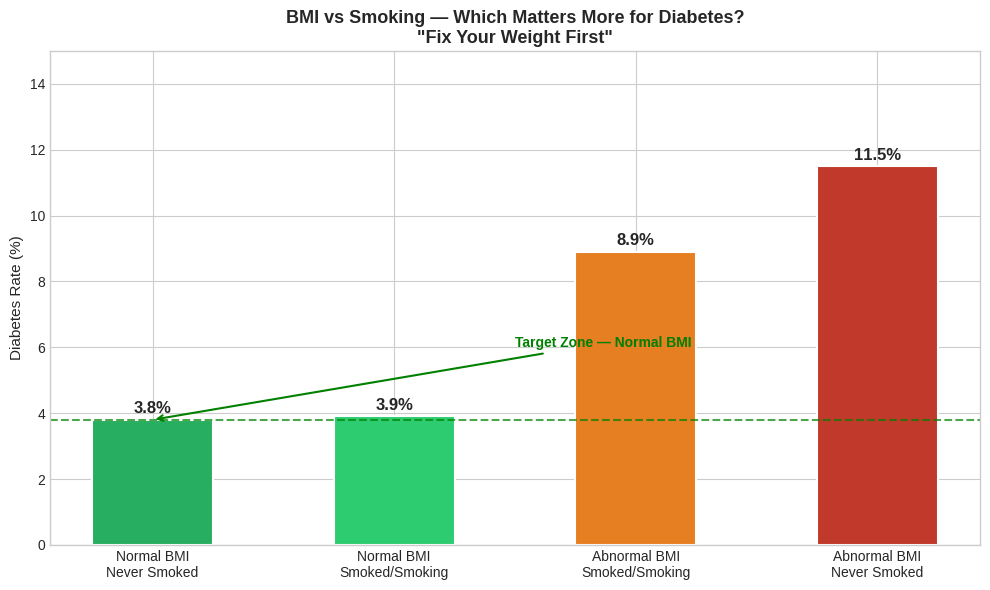

Done!


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

labels = ['Normal BMI\nNever Smoked', 'Normal BMI\nSmoked/Smoking',
          'Abnormal BMI\nSmoked/Smoking', 'Abnormal BMI\nNever Smoked']
rates = [3.8, 3.9, 8.9, 11.5]
colors = ['#27AE60', '#2ECC71', '#E67E22', '#C0392B']

bars = ax.bar(labels, rates, color=colors, edgecolor='white', linewidth=1.5, width=0.5)

for bar, val in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val}%', ha='center', fontsize=12, fontweight='bold')

ax.axhline(y=3.8, color='green', linestyle='--', linewidth=1.5, alpha=0.7)
ax.annotate('Target Zone — Normal BMI',
            xy=(0, 3.8), xytext=(1.5, 6),
            fontsize=10, color='green', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='green', lw=1.5))

ax.set_title('BMI vs Smoking — Which Matters More for Diabetes?\n"Fix Your Weight First"',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Diabetes Rate (%)', fontsize=11)
ax.set_ylim(0, 15)

plt.tight_layout()
plt.savefig('prevention.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done!")

## Part 3: Women's Health — The Most Ignored Chapter

Women face unique health risks that are rarely discussed openly.

Breast cancer, cervical cancer, hormonal conditions —
these are not just "women's problems."
They are India's silent epidemic.

Here we analyze real data to understand risk factors,
survival rates, and what early detection actually means.

In [ ]:
new_datasets = {
    "archive (17).zip": "/content/cancer_types/",
    "archive (19).zip": "/content/breast_cancer/",
    "archive (20).zip": "/content/cervical_cancer/",
    "archive (21).zip": "/content/life_expectancy/"
}

for zip_name, extract_path in new_datasets.items():
    with zipfile.ZipFile(base_path + zip_name, "r") as z:
        z.extractall(extract_path)
        print(f"Extracted: {zip_name} → {extract_path}")

print("\nDone!")

Extracted: archive (17).zip → /content/cancer_types/
Extracted: archive (19).zip → /content/breast_cancer/
Extracted: archive (20).zip → /content/cervical_cancer/
Extracted: archive (21).zip → /content/life_expectancy/

Done!


## Step 23: Loading Women's Health Datasets

In [ ]:
# Load all new datasets
cancer_types = pd.read_csv("/content/cancer_types/cancer_data.csv")
breast_risk = pd.read_csv("/content/breast_cancer/breast_cancer_risk_factors.csv")
breast_survival = pd.read_csv("/content/breast_cancer/breast_cancer_survival_by_stage.csv")
cervical = pd.read_csv("/content/cervical_cancer/kag_risk_factors_cervical_cancer.csv")

# Add to SQL database
cancer_types.to_sql("cancer_types", conn, if_exists="replace", index=False)
breast_risk.to_sql("breast_risk", conn, if_exists="replace", index=False)
breast_survival.to_sql("breast_survival", conn, if_exists="replace", index=False)
cervical.to_sql("cervical", conn, if_exists="replace", index=False)

for name, df in [("Cancer Types", cancer_types), ("Breast Risk", breast_risk),
                  ("Breast Survival", breast_survival), ("Cervical", cervical)]:
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")

Cancer Types: 35 rows, 11 columns
Breast Risk: 12 rows, 7 columns
Breast Survival: 20 rows, 7 columns
Cervical: 858 rows, 36 columns


## Step 24: Breast Cancer — Why Early Detection Saves Lives

In India, most women are diagnosed at Stage 3 or 4 — when it is already late.

Here we show the stark difference in survival rates
between early and late stage detection.
This is the most important chart in this project.

In [ ]:
survival_data = pd.read_sql_query("""
    SELECT
        Stage,
        One_Year_Survival_Pct,
        Five_Year_Survival_Pct,
        Ten_Year_Survival_Pct,
        Pct_Diagnosed_At_Stage
    FROM breast_survival
    WHERE Income_Region = 'High-Income'
    ORDER BY
        CASE Stage
            WHEN 'Stage 0 (DCIS)' THEN 1
            WHEN 'Stage I' THEN 2
            WHEN 'Stage II' THEN 3
            WHEN 'Stage III' THEN 4
            WHEN 'Stage IV' THEN 5
        END
""", conn)

survival_data

,Stage,One_Year_Survival_Pct,Five_Year_Survival_Pct,Ten_Year_Survival_Pct,Pct_Diagnosed_At_Stage
0,Stage 0 (DCIS),100.0,99.5,98.0,20
1,Stage I,100.0,99.0,95.0,30
2,Stage II,98.0,93.0,85.0,35
3,Stage III,92.0,72.0,55.0,12
4,Stage IV,65.0,28.0,12.0,3


## Step 25: Visualizing Survival Rates by Stage

The difference between Stage 1 and Stage 4 detection:
- Stage 1: 99% survive after 5 years
- Stage 4: only 28% survive after 5 years

Early detection is not just important — it is the difference between life and death.

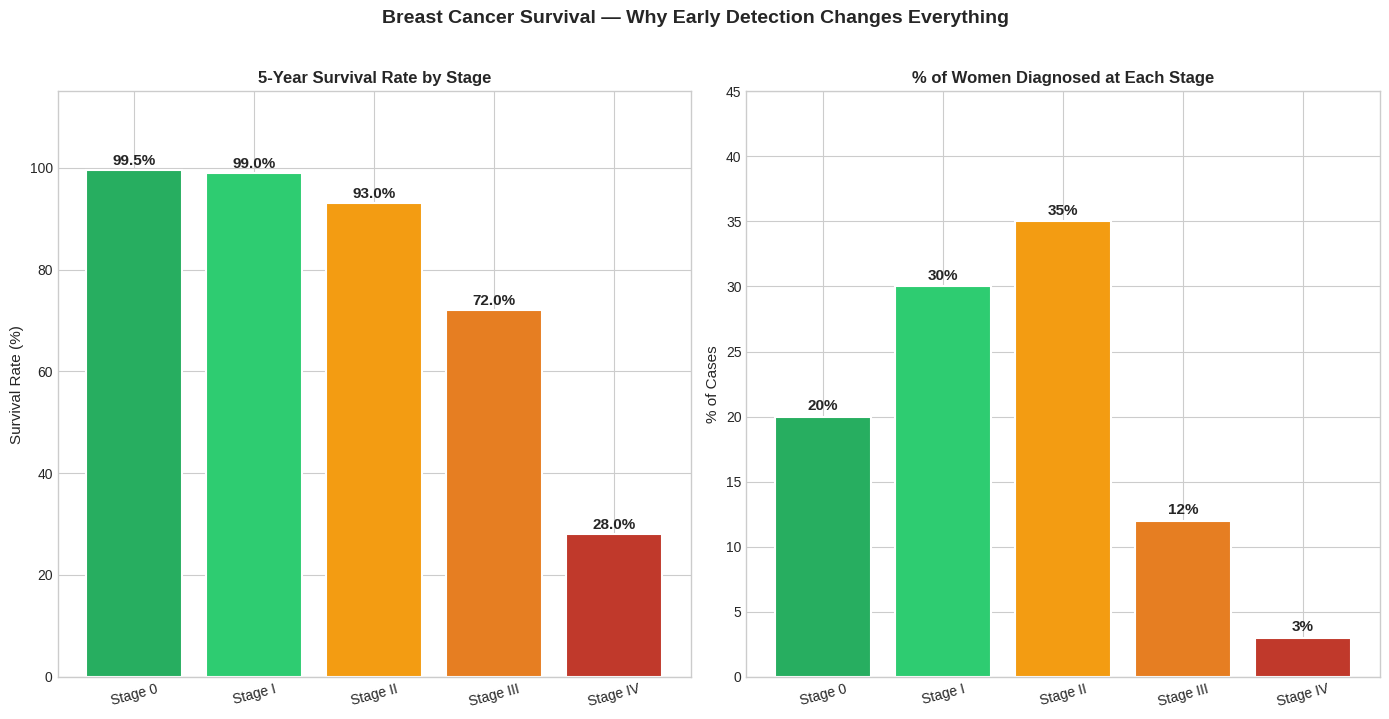

Done!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle('Breast Cancer Survival — Why Early Detection Changes Everything',
             fontsize=14, fontweight='bold', y=1.02)

stages = ['Stage 0', 'Stage I', 'Stage II', 'Stage III', 'Stage IV']
colors = ['#27AE60', '#2ECC71', '#F39C12', '#E67E22', '#C0392B']

# Graph 1 — 5 Year Survival
bars1 = axes[0].bar(stages, survival_data['Five_Year_Survival_Pct'],
                    color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars1, survival_data['Five_Year_Survival_Pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val}%', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('5-Year Survival Rate by Stage', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Survival Rate (%)', fontsize=11)
axes[0].set_ylim(0, 115)
axes[0].tick_params(axis='x', rotation=15)

# Graph 2 — % Diagnosed at Each Stage
bars2 = axes[1].bar(stages, survival_data['Pct_Diagnosed_At_Stage'],
                    color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars2, survival_data['Pct_Diagnosed_At_Stage']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val}%', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('% of Women Diagnosed at Each Stage', fontsize=12, fontweight='bold')
axes[1].set_ylabel('% of Cases', fontsize=11)
axes[1].set_ylim(0, 45)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('breast_cancer_survival.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done!")

## Step 26: What Actually Causes Breast Cancer?

Most women think breast cancer is purely genetic.
The data tells a different story.

Here we analyze which risk factors are modifiable
and which ones we cannot control.

In [ ]:
risk_data = pd.read_sql_query("""
    SELECT
        Risk_Factor,
        Relative_Risk,
        Population_Attributable_Fraction_Pct as PAF_Pct,
        Evidence_Level,
        Modifiable
    FROM breast_risk
    ORDER BY Relative_Risk DESC
""", conn)

risk_data

,Risk_Factor,Relative_Risk,PAF_Pct,Evidence_Level,Modifiable
0,BRCA1/BRCA2 Mutations,5.5,5.0,Strong,0
1,Radiation Exposure (Chest),4.0,1.5,Strong,0
2,Age (50+),3.0,30.0,Strong,0
3,Family History,2.1,12.0,Strong,0
4,Dense Breast Tissue,2.0,16.0,Strong,0
5,Hormone Therapy (HRT),1.7,4.0,Strong,1
6,Obesity (Post-Menopause),1.5,10.0,Strong,1
7,Alcohol Consumption,1.5,7.0,Strong,1
8,Nulliparity / Late First Birth,1.4,6.0,Moderate,0
9,Early Menarche (<12),1.3,8.0,Moderate,0


## Step 27: Visualizing Breast Cancer Risk Factors

Most people fear genetics — but data shows age and lifestyle matter more.

Modifiable factors (things you can change) account for 26% of breast cancer cases.
Non-modifiable factors account for 74% — but most of these are detectable early.

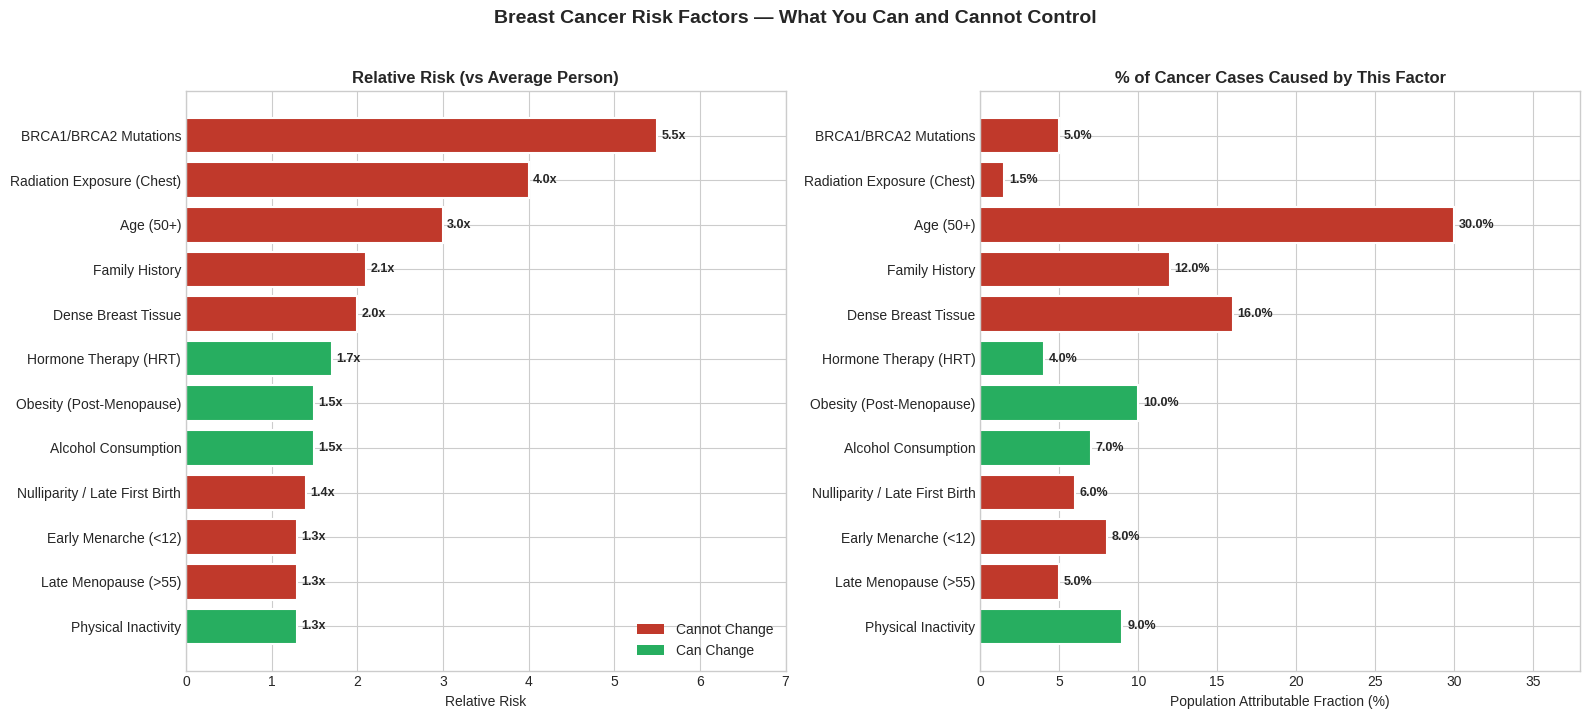

Done!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Breast Cancer Risk Factors — What You Can and Cannot Control',
             fontsize=14, fontweight='bold', y=1.02)

# Colors based on modifiable
colors = ['#C0392B' if m == 0 else '#27AE60' for m in risk_data['Modifiable']]

# Graph 1 — Relative Risk
bars1 = axes[0].barh(risk_data['Risk_Factor'][::-1],
                     risk_data['Relative_Risk'][::-1],
                     color=colors[::-1], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars1, risk_data['Relative_Risk'][::-1]):
    axes[0].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f'{val}x', va='center', fontsize=9, fontweight='bold')
axes[0].set_title('Relative Risk (vs Average Person)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Relative Risk')
axes[0].set_xlim(0, 7)

# Graph 2 — Population Impact
bars2 = axes[1].barh(risk_data['Risk_Factor'][::-1],
                     risk_data['PAF_Pct'][::-1],
                     color=colors[::-1], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars2, risk_data['PAF_Pct'][::-1]):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val}%', va='center', fontsize=9, fontweight='bold')
axes[1].set_title('% of Cancer Cases Caused by This Factor', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Population Attributable Fraction (%)')
axes[1].set_xlim(0, 38)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#C0392B', label='Cannot Change'),
                   Patch(facecolor='#27AE60', label='Can Change')]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('breast_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done!")

## Step 28: PCOS — India's Most Underdiagnosed Condition

1 in 5 Indian women have PCOS (Polycystic Ovary Syndrome).
Most don't know it until they face fertility issues.

What the data and research tells us:

WHAT IS PCOS?
Hormonal imbalance where ovaries produce excess androgens (male hormones).
Key marker: AMH (Anti-Mullerian Hormone) — elevated in PCOS patients.
In our dataset: 177 out of 541 women (32.7%) tested PCOS positive.

COMMON SYMPTOMS INDIA IGNORES:
- Irregular periods — dismissed as "stress"
- Unexplained weight gain — blamed on diet
- Excess facial/body hair — considered cosmetic
- Constant fatigue and brain fog
- Acne and hair thinning

WHY IT MATTERS BEYOND FERTILITY:
- PCOS women have 3x higher risk of Type 2 Diabetes
- 2x higher risk of cardiovascular disease
- Higher risk of endometrial cancer if untreated
- Strong link with depression and anxiety

THE FREE INTERVENTIONS THAT ACTUALLY WORK:
- 5-10% weight loss reduces PCOS symptoms by 40-60%
- 150 minutes of moderate exercise per week regulates hormones
- Low glycemic index diet stabilizes insulin levels
- Sleep regulation directly impacts androgen levels

Bottom line: PCOS is not just a fertility problem.
It is a metabolic condition that affects your entire life.
Early diagnosis costs less than ignoring it.

In [ ]:
amh_data = pd.read_sql_query("""
    SELECT
        "PCOS (Y/N)" as PCOS_Status,
        COUNT(*) as Total_Patients,
        ROUND(AVG("AMH(ng/mL)"), 2) as Avg_AMH,
        ROUND(MIN("AMH(ng/mL)"), 2) as Min_AMH,
        ROUND(MAX("AMH(ng/mL)"), 2) as Max_AMH
    FROM pcos
    GROUP BY "PCOS (Y/N)"
""", conn)

amh_data['PCOS_Status'] = amh_data['PCOS_Status'].map({0: 'No PCOS', 1: 'PCOS Positive'})
amh_data

,PCOS_Status,Total_Patients,Avg_AMH,Min_AMH,Max_AMH
0,No PCOS,364,4.53,0.16,0.0
1,PCOS Positive,177,7.84,0.10,9.9


## Step 29: AMH Levels — The Key PCOS Marker

AMH (Anti-Mullerian Hormone) is the most reliable PCOS indicator.

PCOS positive women have nearly 2x higher AMH levels (7.84 vs 4.53).
Normal AMH range: 1.0 - 3.5 ng/mL
Above 3.5: Possible PCOS — get tested.

Note: This dataset contains women already suspected of hormonal issues,
which is why even the "No PCOS" group shows elevated AMH.
In general population, No PCOS average would be lower.

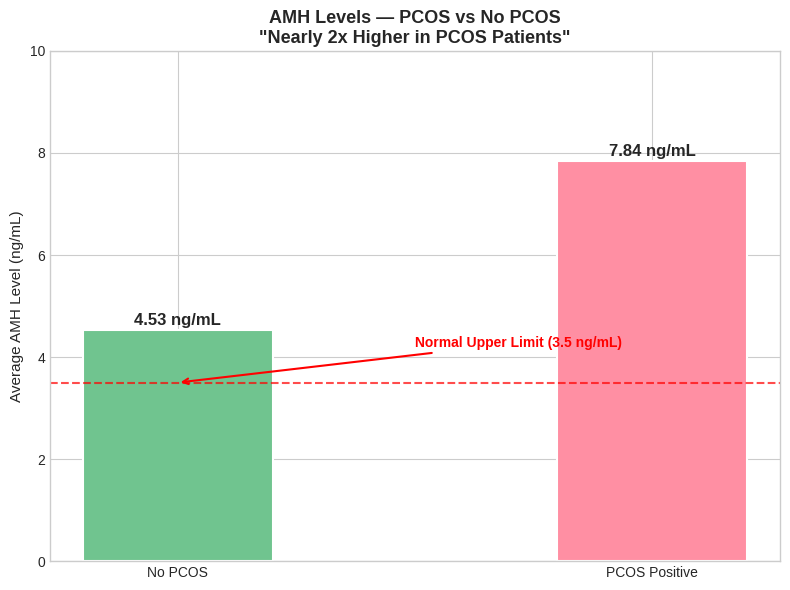

Done!


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#70C48F', '#FF8FA3']
bars = ax.bar(amh_data['PCOS_Status'], amh_data['Avg_AMH'],
              color=colors, edgecolor='white', linewidth=1.5, width=0.4)

for bar, val in zip(bars, amh_data['Avg_AMH']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val} ng/mL', ha='center', fontsize=12, fontweight='bold')

ax.axhline(y=3.5, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax.annotate('Normal Upper Limit (3.5 ng/mL)',
            xy=(0, 3.5), xytext=(0.5, 4.2),
            fontsize=10, color='red', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

ax.set_title('AMH Levels — PCOS vs No PCOS\n"Nearly 2x Higher in PCOS Patients"',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Average AMH Level (ng/mL)', fontsize=11)
ax.set_ylim(0, 10)

plt.tight_layout()
plt.savefig('pcos_amh.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done!")

## Step 30: Women's Health — The Complete Picture

Bringing it all together — breast cancer, cervical cancer, PCOS, and overall cancer burden.

4 key insights:
1. Breast cancer is India's most common cancer — early detection saves lives
2. Cervical cancer risk peaks after 50 — almost entirely preventable
3. PCOS affects 1 in 5 women — AMH levels nearly 2x higher in positive cases
4. Modifiable lifestyle factors account for 26% of breast cancer cases

In [ ]:
# Cervical cancer age-wise — SQL query
cervical_age = pd.read_sql_query("""
    SELECT
        CASE
            WHEN Age < 20 THEN 'Under 20'
            WHEN Age BETWEEN 20 AND 29 THEN '20-29'
            WHEN Age BETWEEN 30 AND 39 THEN '30-39'
            WHEN Age BETWEEN 40 AND 49 THEN '40-49'
            ELSE '50+'
        END as Age_Group,
        ROUND(AVG(CAST("Smokes" AS FLOAT)) * 100, 1) as Smoking_Rate,
        ROUND(AVG(CAST("Hormonal Contraceptives" AS FLOAT)) * 100, 1) as Contraceptive_Rate,
        ROUND(AVG(CAST("STDs" AS FLOAT)) * 100, 1) as STD_Rate,
        ROUND(AVG(CAST("Biopsy" AS FLOAT)) * 100, 1) as Cancer_Positive_Rate,
        COUNT(*) as Total_Patients
    FROM cervical
    WHERE Age < 80
    GROUP BY Age_Group
    ORDER BY MIN(Age)
""", conn)

# Top cancers — SQL query
cancer_type_data = pd.read_sql_query("""
    SELECT
        cancer_type,
        new_cases_number,
        "Deaths Number" as Deaths,
        new_case_percent,
        death_percentage
    FROM cancer_types
    ORDER BY new_cases_number DESC
    LIMIT 10
""", conn)

# Breast survival — SQL query
survival_data = pd.read_sql_query("""
    SELECT
        Stage,
        Five_Year_Survival_Pct,
        Pct_Diagnosed_At_Stage
    FROM breast_survival
    WHERE Income_Region = 'High-Income'
    ORDER BY
        CASE Stage
            WHEN 'Stage 0 (DCIS)' THEN 1
            WHEN 'Stage I' THEN 2
            WHEN 'Stage II' THEN 3
            WHEN 'Stage III' THEN 4
            WHEN 'Stage IV' THEN 5
        END
""", conn)

# Breast risk factors — SQL query
risk_data = pd.read_sql_query("""
    SELECT
        Risk_Factor,
        Relative_Risk,
        Population_Attributable_Fraction_Pct as PAF_Pct,
        Modifiable
    FROM breast_risk
    ORDER BY Relative_Risk DESC
""", conn)

# PCOS AMH — SQL query
amh_data = pd.read_sql_query("""
    SELECT
        CASE "PCOS (Y/N)"
            WHEN 0 THEN 'No PCOS'
            WHEN 1 THEN 'PCOS Positive'
        END as PCOS_Status,
        COUNT(*) as Total_Patients,
        ROUND(AVG("AMH(ng/mL)"), 2) as Avg_AMH
    FROM pcos
    GROUP BY "PCOS (Y/N)"
""", conn)

print("All data loaded via SQL!")
print(f"Cervical: {len(cervical_age)} age groups")
print(f"Cancer types: {len(cancer_type_data)} cancers")
print(f"Breast survival: {len(survival_data)} stages")
print(f"Breast risk: {len(risk_data)} factors")
print(f"PCOS: {len(amh_data)} groups")

All data loaded via SQL!
Cervical: 5 age groups
Cancer types: 10 cancers
Breast survival: 5 stages
Breast risk: 12 factors
PCOS: 2 groups


## Step 30: Visualizing Women's Health — The Complete Picture

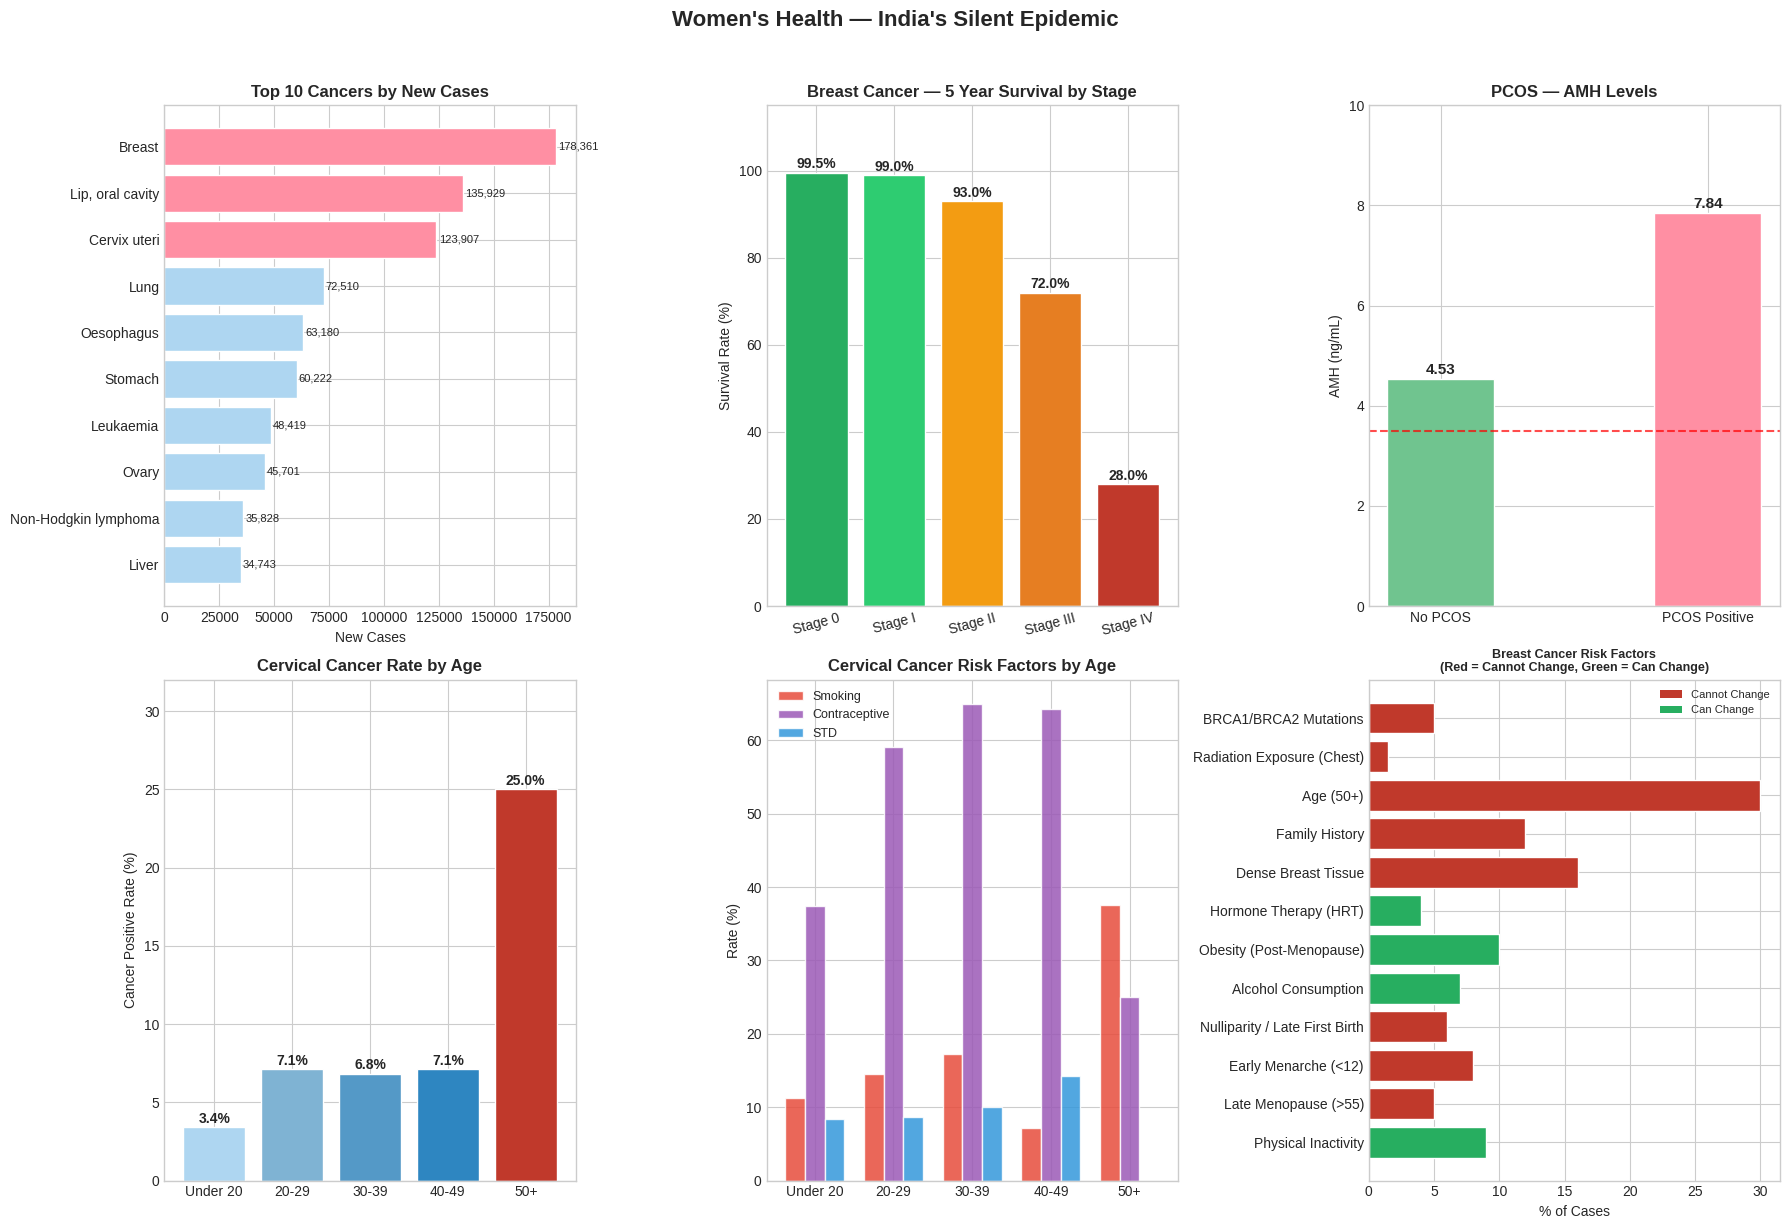

Done!


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Women's Health — India's Silent Epidemic",
             fontsize=16, fontweight='bold', y=1.02)

# Graph 1 — Top Cancer Types
colors1 = ['#FF8FA3' if i < 3 else '#AED6F1' for i in range(10)]
axes[0,0].barh(cancer_type_data['cancer_type'][::-1],
               cancer_type_data['new_cases_number'][::-1],
               color=colors1[::-1], edgecolor='white')
for i, val in enumerate(cancer_type_data['new_cases_number'][::-1]):
    axes[0,0].text(val + 1000, i, f'{val:,}', va='center', fontsize=8)
axes[0,0].set_title('Top 10 Cancers by New Cases', fontweight='bold')
axes[0,0].set_xlabel('New Cases')

# Graph 2 — Breast Cancer Survival
stages = ['Stage 0', 'Stage I', 'Stage II', 'Stage III', 'Stage IV']
colors2 = ['#27AE60', '#2ECC71', '#F39C12', '#E67E22', '#C0392B']
bars2 = axes[0,1].bar(stages, survival_data['Five_Year_Survival_Pct'],
                      color=colors2, edgecolor='white')
for bar, val in zip(bars2, survival_data['Five_Year_Survival_Pct']):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                  f'{val}%', ha='center', fontsize=10, fontweight='bold')
axes[0,1].set_title('Breast Cancer — 5 Year Survival by Stage', fontweight='bold')
axes[0,1].set_ylabel('Survival Rate (%)')
axes[0,1].set_ylim(0, 115)
axes[0,1].tick_params(axis='x', rotation=15)

# Graph 3 — PCOS AMH
colors3 = ['#70C48F', '#FF8FA3']
bars3 = axes[0,2].bar(amh_data['PCOS_Status'], amh_data['Avg_AMH'],
                      color=colors3, edgecolor='white', width=0.4)
for bar, val in zip(bars3, amh_data['Avg_AMH']):
    axes[0,2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                  f'{val}', ha='center', fontsize=11, fontweight='bold')
axes[0,2].axhline(y=3.5, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
axes[0,2].set_title('PCOS — AMH Levels', fontweight='bold')
axes[0,2].set_ylabel('AMH (ng/mL)')
axes[0,2].set_ylim(0, 10)

# Graph 4 — Cervical Cancer Rate by Age
colors4 = ['#AED6F1', '#7FB3D3', '#5499C7', '#2E86C1', '#C0392B']
bars4 = axes[1,0].bar(cervical_age['Age_Group'],
                      cervical_age['Cancer_Positive_Rate'],
                      color=colors4, edgecolor='white')
for bar, val in zip(bars4, cervical_age['Cancer_Positive_Rate']):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                  f'{val}%', ha='center', fontsize=10, fontweight='bold')
axes[1,0].set_title('Cervical Cancer Rate by Age', fontweight='bold')
axes[1,0].set_ylabel('Cancer Positive Rate (%)')
axes[1,0].set_ylim(0, 32)

# Graph 5 — Cervical Risk Factors
x = range(len(cervical_age['Age_Group']))
width = 0.25
for i, (col, label, color) in enumerate(zip(
    ['Smoking_Rate', 'Contraceptive_Rate', 'STD_Rate'],
    ['Smoking', 'Contraceptive', 'STD'],
    ['#E74C3C', '#9B59B6', '#3498DB']
)):
    axes[1,1].bar([xi + i*width for xi in x], cervical_age[col],
                  width=width, label=label, color=color, alpha=0.85, edgecolor='white')
axes[1,1].set_title('Cervical Cancer Risk Factors by Age', fontweight='bold')
axes[1,1].set_ylabel('Rate (%)')
axes[1,1].set_xticks([xi + width for xi in x])
axes[1,1].set_xticklabels(cervical_age['Age_Group'])
axes[1,1].legend(fontsize=9)

# Graph 6 — Breast Risk Factors (modifiable vs not)
colors6 = ['#C0392B' if m == 0 else '#27AE60' for m in risk_data['Modifiable']]
axes[1,2].barh(risk_data['Risk_Factor'][::-1],
               risk_data['PAF_Pct'][::-1],
               color=colors6[::-1], edgecolor='white')
axes[1,2].set_title('Breast Cancer Risk Factors\n(Red = Cannot Change, Green = Can Change)',
                    fontweight='bold', fontsize=9)
axes[1,2].set_xlabel('% of Cases')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#C0392B', label='Cannot Change'),
                   Patch(facecolor='#27AE60', label='Can Change')]
axes[1,2].legend(handles=legend_elements, fontsize=8)

plt.tight_layout()
plt.savefig('womens_health_complete.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done!")

## Step 31: Men vs Women — Who Is More At Risk?

Diabetes, BMI, blood glucose — do men and women differ significantly?

Most health studies focus on one gender.
Here we compare both using 1,00,000 real clinical records.

In [ ]:
combined = pd.read_sql_query("""
    SELECT
        gender,
        COUNT(*) as Total_Patients,
        ROUND(SUM(diabetes) * 100.0 / COUNT(*), 1) as Diabetes_Rate,
        ROUND(AVG(bmi), 1) as Avg_BMI,
        ROUND(AVG(HbA1c_level), 2) as Avg_HbA1c,
        ROUND(AVG(blood_glucose_level), 1) as Avg_Glucose
    FROM diabetes
    WHERE gender IN ('Male', 'Female')
    GROUP BY gender
""", conn)

combined

,gender,Total_Patients,Diabetes_Rate,Avg_BMI,Avg_HbA1c,Avg_Glucose
0,Female,58552,7.6,27.4,5.51,137.5
1,Male,41430,9.7,27.1,5.55,138.9


## Step 32: Visualizing Gender Differences in Diabetes Risk

Men have 28% higher diabetes rate than women — despite similar BMI.

This suggests hormonal differences play a significant role.
Women's hormones (estrogen) provide some metabolic protection —
but this protection disappears after menopause.*italicised text*

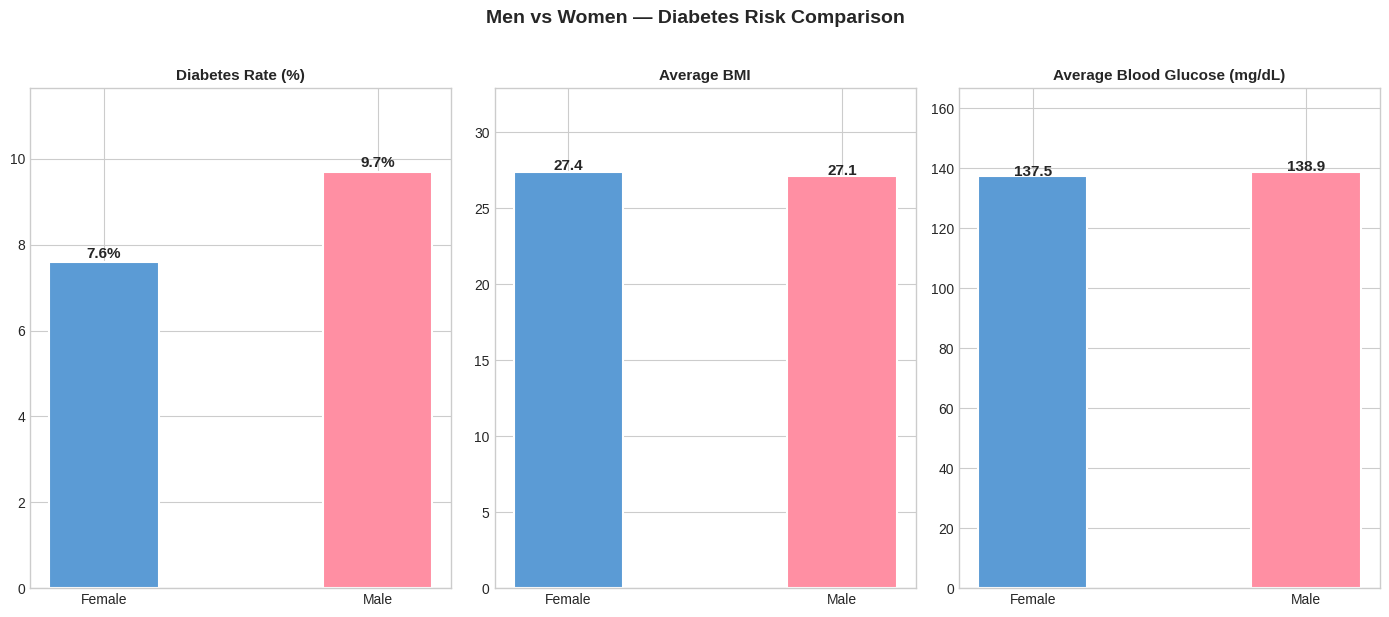

Done!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6))
fig.suptitle('Men vs Women — Diabetes Risk Comparison',
             fontsize=14, fontweight='bold', y=1.02)

metrics = [
    ('Diabetes_Rate', 'Diabetes Rate (%)', '%'),
    ('Avg_BMI', 'Average BMI', ''),
    ('Avg_Glucose', 'Average Blood Glucose (mg/dL)', '')
]

colors = ['#5B9BD5', '#FF8FA3']

for ax, (col, title, unit) in zip(axes, metrics):
    bars = ax.bar(combined['gender'], combined[col],
                  color=colors, edgecolor='white', linewidth=1.5, width=0.4)
    for bar, val in zip(bars, combined[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val}{unit}', ha='center', fontsize=11, fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylim(0, combined[col].max() * 1.2)

plt.tight_layout()
plt.savefig('gender_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done!")

## Final Conclusions — Your Parents' Health Is Your Future

After analyzing 5,17,000+ real patient records across 7 datasets:

DIABETES
- Risk increases 15x from your 20s to 60s — turning point is your 30s
- Normal BMI reduces diabetes risk to 3.8% regardless of smoking
- Hypertension + Heart Disease together = 6.4x higher diabetes risk
- Men have 28% higher diabetes rate than women despite similar BMI
- Estrogen provides metabolic protection — but disappears after menopause

FITNESS PARADOX
- Active smoker (13%) is healthier than inactive non-smoker (18%)
- Exercise is powerful — but cannot fully cancel out smoking
- Active non-smoker (9.3%) is always the best outcome

HEART DISEASE
- 80% of men above 60 show signs of heart disease
- Women's risk catches up sharply after 50 — post menopause effect
- Gender is not protection — it is just a delay

CANCER
- Breast cancer is India's most common cancer — 1,78,361 new cases
- Stage 1 detection = 99% survival. Stage 4 = only 28% survival
- Modifiable lifestyle factors cause 26% of breast cancer cases
- Cervical cancer risk peaks at 50+ — 25% positive rate — almost entirely preventable

PCOS
- 32.7% of suspected hormonal cases tested PCOS positive
- AMH levels nearly 2x higher in PCOS patients (7.84 vs 4.53 ng/mL)
- PCOS women have 3x higher diabetes risk if untreated
- 5-10% weight loss restores ovulation in majority of cases

BOTTOM LINE
Your genes load the gun.
Your lifestyle pulls the trigger.
But early awareness can remove the bullet entirely.

Healthcare is expensive. Awareness is free.
The best time to start was yesterday. The next best time is today.

## Step 33: Prevention Without Money — What Science Actually Says

Healthcare in India is expensive. These interventions are free.
All backed by peer-reviewed research.

DIABETES PREVENTION
- 30 minutes brisk walking daily reduces diabetes risk by 30% (NEJM, 2002)
- Losing 5-7% body weight cuts diabetes risk by 58% (Diabetes Prevention Program)
- Replacing white rice with millets reduces blood glucose spikes by 30-40%
- Less than 6 hours sleep = 2x higher diabetes risk (Annals of Internal Medicine)

HEART DISEASE PREVENTION
- 150 minutes moderate exercise per week reduces heart disease risk by 35%
- Reducing salt intake by 5g/day lowers blood pressure by 5-6 mmHg
- Quitting smoking reduces heart attack risk by 50% within 1 year
- Stress management through meditation directly reduces cortisol and BP

CANCER PREVENTION
- Maintaining normal BMI reduces breast cancer risk by 30-40% post menopause
- Avoiding alcohol reduces breast cancer risk by 7% per drink per day
- Regular self breast examination every month catches Stage 1 tumors
- Cervical cancer is 99% preventable with HPV vaccine and regular Pap smear

PCOS MANAGEMENT
- 5-10% weight loss restores ovulation in 55-100% of women (Human Reproduction)
- 150 min/week exercise significantly reduces androgen levels
- Low glycemic diet stabilizes insulin and directly reduces PCOS symptoms
- 7-9 hours sleep regulates cortisol and androgen production

FOR EVERYONE
- Drink 2-3 liters water daily — reduces kidney disease risk by 50%
- 10 minutes sunlight daily — Vitamin D deficiency linked to 17 diseases
- Know your family health history — share it, act on it early
- Annual blood tests after 25 — HbA1c, lipid profile, vitamin D, thyroid

Bottom line: The most powerful medicine is free.
It is called awareness, movement, and sleep.